In [1]:
import scarf

scarf.set_verbosity('WARNING')
scarf.__version__

'1.0.0'

In [2]:
scarf.fetch_dataset(
    'tenx_8K_pbmc_citeseq',
    save_path='scarf_datasets',
    as_zarr=True,
)

In [3]:
ds = scarf.DataStore(
    'scarf_datasets/tenx_8K_pbmc_citeseq/data.zarr',
    default_assay='RNA',
    nthreads=4
)

In [4]:
ds

DataStore has 7549 (7865) cells with 2 assays: ADT RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'ADT_nFeatures', 
            'RNA_tSNE2', 'ADT_UMAP2', 'ADT_UMAP1', 'RNA_tSNE1', 'RNA_nFeatures', 
            'ADT_nCounts', 'RNA_percentRibo', 'RNA_nCounts', 'RNA_cluster', 'RNA_UMAP2', 
            'RNA_leiden_cluster', 'ADT_leiden_cluster', 'RNA_UMAP1'
   ADT assay has 14 (17) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          
   RNA assay has 13550 (33538) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
            'I__hvgs'

In [5]:
ds.RNA.feats.head()

,I,ids,names,nCells,I__hvgs,dropOuts
0,False,ENSG00000243485,MIR1302-2HG,0,False,7865
1,False,ENSG00000237613,FAM138A,0,False,7865
2,False,ENSG00000186092,OR4F5,0,False,7865
3,False,ENSG00000238009,AL627309.1,12,False,7853
4,False,ENSG00000239945,AL627309.3,0,False,7865


In [6]:
ds.ADT.feats.head()

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1


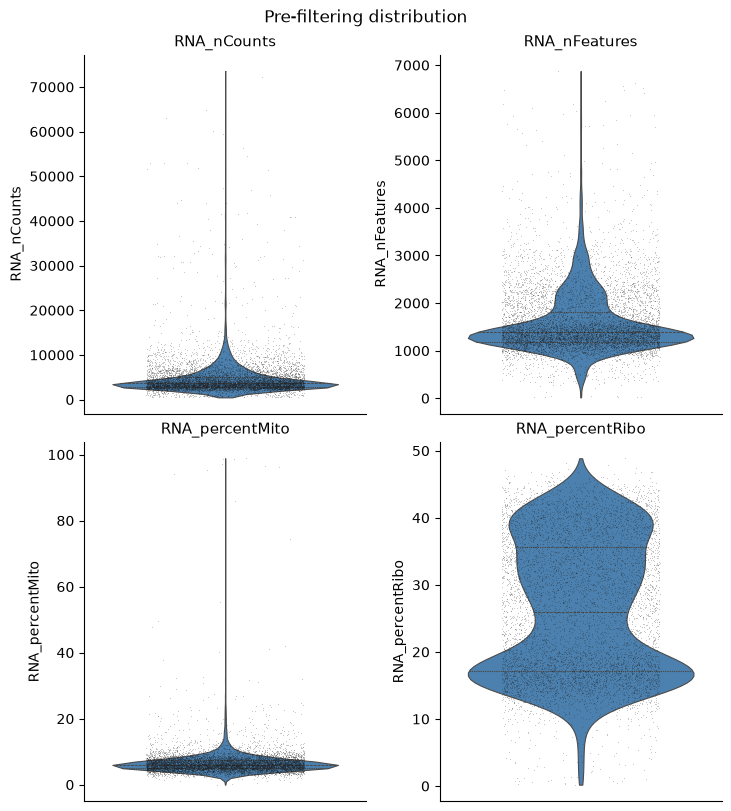

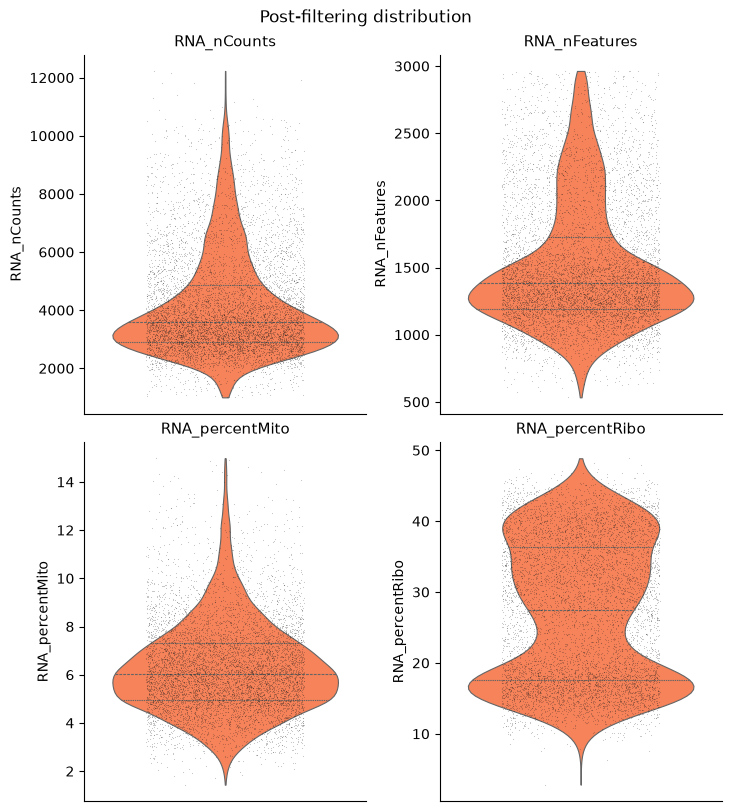

In [7]:
ds.auto_filter_cells()

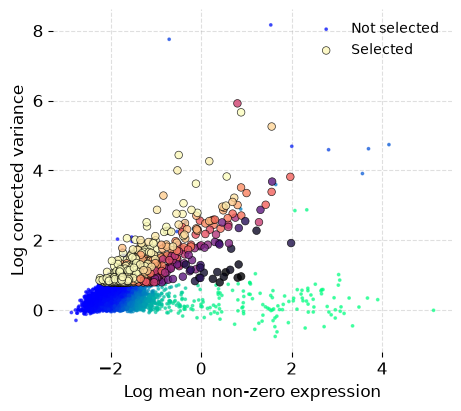

In [8]:
ds.mark_hvgs(
    min_cells=20,
    top_n=1000,
    min_mean=-3,
    max_mean=2,
    max_var=6
)

ds.make_graph(
    feat_key='hvgs',
    k=21,
    dims=15,
    n_centroids=100
)

ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True
)

ds.run_leiden_clustering(resolution=1)

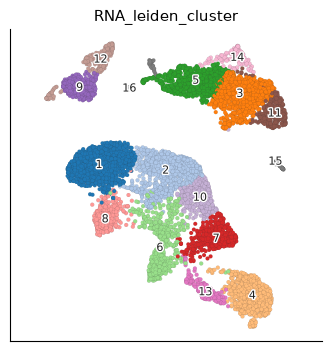

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [9]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
)

In [10]:
ds.ADT.feats.head(n=ds.ADT.feats.N)

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1
5,True,CD16,CD16_TotalSeqB,7864,1
6,True,CD56,CD56_TotalSeqB,7864,1
7,True,CD19,CD19_TotalSeqB,7702,163
8,True,CD25,CD25_TotalSeqB,7861,4
9,True,CD45RA,CD45RA_TotalSeqB,7864,1


In [11]:
adt_names = ds.ADT.feats.to_pandas_dataframe(['names'])['names']
adt_names

0               CD3_TotalSeqB
1               CD4_TotalSeqB
2              CD8a_TotalSeqB
3              CD14_TotalSeqB
4              CD15_TotalSeqB
5              CD16_TotalSeqB
6              CD56_TotalSeqB
7              CD19_TotalSeqB
8              CD25_TotalSeqB
9            CD45RA_TotalSeqB
10           CD45RO_TotalSeqB
11             PD-1_TotalSeqB
12            TIGIT_TotalSeqB
13            CD127_TotalSeqB
14    IgG2a_control_TotalSeqB
15     IgG1_control_TotalSeqB
16    IgG2b_control_TotalSeqB
Name: names, dtype: object

In [12]:
is_control = adt_names.str.contains('control').values
is_control

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True,  True,  True])

In [13]:
ds.ADT.feats.update_key(~is_control, 'I')
ds.ADT.feats.head(n=ds.ADT.feats.N)

,I,ids,names,nCells,dropOuts
0,True,CD3,CD3_TotalSeqB,7864,1
1,True,CD4,CD4_TotalSeqB,7864,1
2,True,CD8a,CD8a_TotalSeqB,7863,2
3,True,CD14,CD14_TotalSeqB,7864,1
4,True,CD15,CD15_TotalSeqB,7864,1
5,True,CD16,CD16_TotalSeqB,7864,1
6,True,CD56,CD56_TotalSeqB,7864,1
7,True,CD19,CD19_TotalSeqB,7702,163
8,True,CD25,CD25_TotalSeqB,7861,4
9,True,CD45RA,CD45RA_TotalSeqB,7864,1


In [14]:
print (ds.ADT)
print (ds.ADT.normMethod.__name__)

ADTassay ADT with 14(17) features
norm_clr


In [15]:
ds.make_graph(
    from_assay='ADT',
    feat_key='I', 
    k=21,
    dims=0,
    n_centroids=100
)

In [16]:
ds.run_umap(
    from_assay='ADT',
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True
)

ds.run_leiden_clustering(
    from_assay='ADT',
    resolution=1
)

In [17]:
ds.cells.head()

,I,ids,names,RNA_percentMito,RNA_tSNE2,ADT_nFeatures,ADT_UMAP2,RNA_tSNE1,ADT_UMAP1,RNA_percentRibo,RNA_cluster,RNA_nCounts,RNA_nFeatures,ADT_nCounts,RNA_UMAP2,RNA_leiden_cluster,ADT_leiden_cluster,RNA_UMAP1
0,True,AAACCCAAGATTGTGA-1,AAACCCAAGATTGTGA-1,8.668831,-18.08830,17.0,-14.198792,-4.26865,-20.750818,15.259740,4,6160.0,2194.0,981.0,21.210798,3,4,25.322105
1,True,AAACCCACATCGGTTA-1,AAACCCACATCGGTTA-1,6.316103,-14.88920,17.0,-5.512753,5.02671,-14.229106,19.037688,4,6713.0,2093.0,1475.0,17.747095,3,14,26.267963
2,True,AAACCCAGTACCGCGT-1,AAACCCAGTACCGCGT-1,8.056090,-18.83030,17.0,-5.933149,-14.91320,-17.818312,16.002200,5,3637.0,1518.0,7149.0,20.963030,3,4,15.451259
3,True,AAACCCAGTATCGAAA-1,AAACCCAGTATCGAAA-1,9.003215,-3.35003,17.0,-18.456493,16.69630,24.142471,18.729904,3,1244.0,737.0,6831.0,-29.279469,4,2,19.915602
4,True,AAACCCAGTCGTCATA-1,AAACCCAGTCGTCATA-1,6.204519,-1.37607,17.0,-20.919519,18.37000,22.803093,16.353887,3,2611.0,1240.0,6839.0,-34.785088,4,2,19.599966


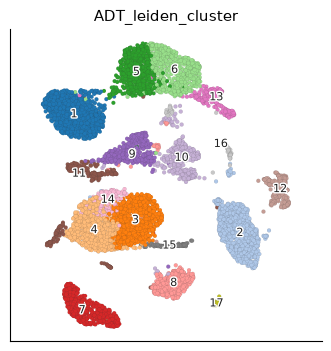

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [18]:
ds.plots.embedding(
    layout_key='ADT_UMAP',
    color_by='ADT_leiden_cluster',
)

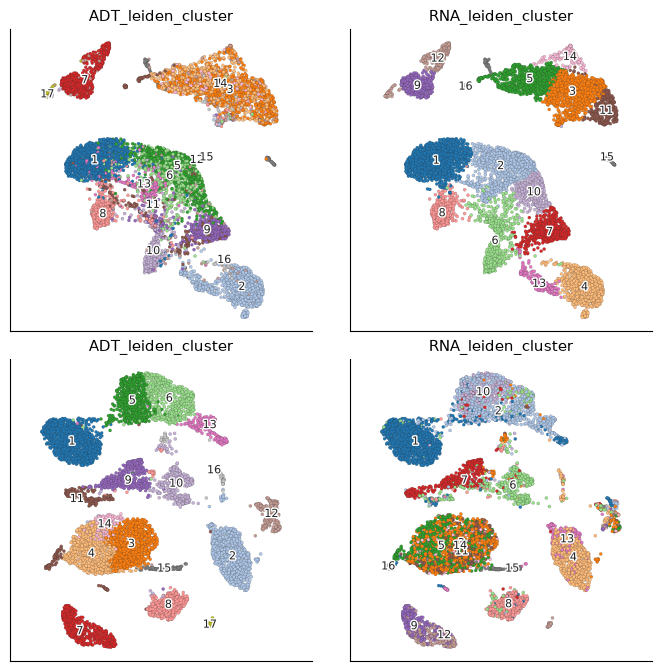

PlotResult(axes=4, tables=0, legends=4, scales=6, owns_figure=True, rendered=True)

In [19]:
# UMAP on RNA and coloured with clusters calculated on ADT
ds.plots.embedding(
    layout_key=['RNA_UMAP', 'ADT_UMAP'],
    color_by=['ADT_leiden_cluster', 'RNA_leiden_cluster'],
    n_columns=2,
    point_size=5,
    legend_loc='on_data',
)

In [20]:
import pandas as pd

df = pd.crosstab(
    ds.cells.fetch('RNA_leiden_cluster'),
    ds.cells.fetch('ADT_leiden_cluster')
)
df

col_0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
row_0,,,,,,,,,,,,,,,,,
1,1023,0,0,0,48,24,0,18,2,3,26,17,46,0,0,0,0
2,30,0,0,0,336,311,0,1,4,13,7,21,160,0,0,0,0
3,0,12,406,275,1,7,1,11,4,4,0,49,2,62,0,23,0
4,1,722,0,0,0,1,0,0,0,1,0,27,1,0,0,28,0
5,0,2,213,309,0,1,0,0,0,0,32,17,0,62,6,3,0
6,17,4,0,0,5,57,0,38,65,303,46,27,0,0,0,3,0
7,0,2,0,0,30,7,0,3,328,10,80,12,0,0,0,0,0
8,2,0,0,0,1,0,0,353,7,7,13,5,1,0,0,0,0
9,0,0,0,0,0,1,328,0,0,0,0,7,0,0,0,0,0


In [21]:
(100 * df.max()/df.sum()).sort_values(ascending=False)

col_0
17    100.000000
1      95.251397
10     86.819484
15     86.301370
8      82.284382
2      80.670391
9      79.036145
13     75.829384
7      63.076923
6      58.901515
5      58.232236
3      48.798077
16     45.161290
14     43.661972
4      42.620690
11     32.786885
12     20.762712
dtype: float64

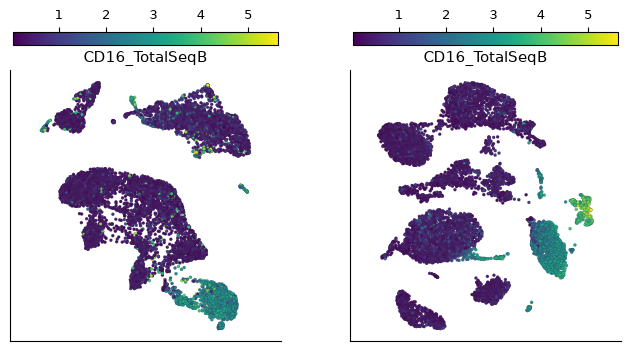

PlotResult(axes=2, tables=0, legends=2, scales=2, owns_figure=True, rendered=True)

In [22]:
ds.plots.embedding(
    layout_key=['RNA_UMAP', 'ADT_UMAP'],
    color_by='CD16_TotalSeqB',
    from_assay='ADT',
    n_columns=2,
    point_size=5,
)

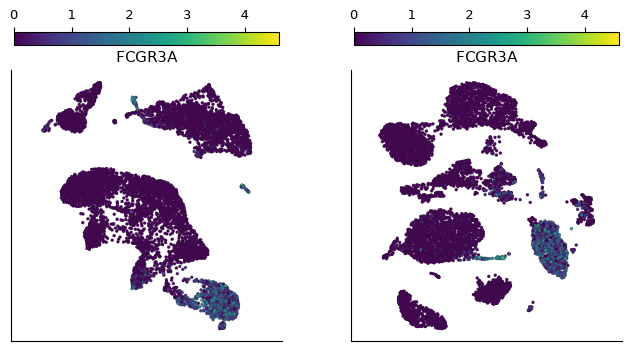

PlotResult(axes=2, tables=0, legends=2, scales=2, owns_figure=True, rendered=True)

In [23]:
ds.plots.embedding(
    layout_key=['RNA_UMAP', 'ADT_UMAP'],
    color_by='FCGR3A',
    from_assay='RNA',
    n_columns=2,
    point_size=5,
)

In [24]:
ds.integrate_assays(
    assays=['RNA', 'ADT'],
    label='RNA+ADT',
    method='snn',
)

In [25]:
ds.run_umap(
    integrated_graph='RNA+ADT',
    n_epochs=500,
    spread=5,
    min_dist=0.5,
    parallel=True
)

ds.run_leiden_clustering(
    integrated_graph='RNA+ADT',
    resolution=1.75
)

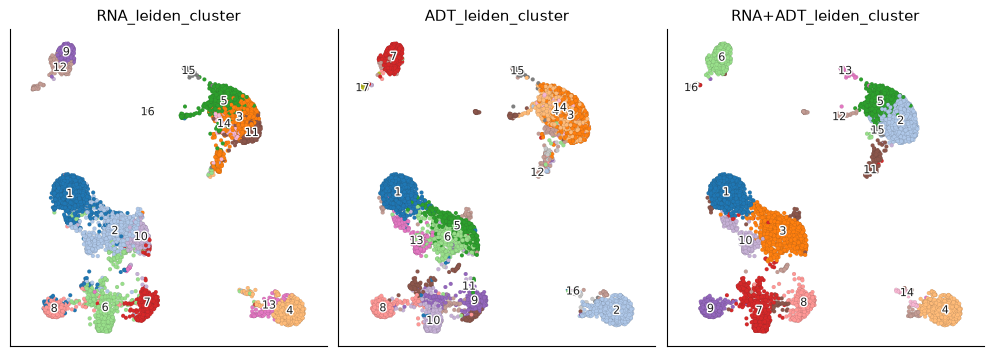

PlotResult(axes=3, tables=0, legends=3, scales=4, owns_figure=True, rendered=True)

In [26]:
ds.plots.embedding(
    layout_key='RNA+ADT_UMAP',
    color_by=[
        'RNA_leiden_cluster',
        'ADT_leiden_cluster',
        'RNA+ADT_leiden_cluster',
    ],
    legend_loc='on_data',
    n_columns=3,
)

In [27]:
ds.cells.columns

['I',
 'ids',
 'names',
 'RNA_tSNE2',
 'ADT_nFeatures',
 'RNA_percentMito',
 'RNA+ADT_UMAP1',
 'RNA_tSNE1',
 'ADT_UMAP1',
 'ADT_UMAP2',
 'ADT_nCounts',
 'RNA_percentRibo',
 'RNA_nFeatures',
 'RNA+ADT_leiden_cluster',
 'RNA_nCounts',
 'RNA_cluster',
 'RNA+ADT_UMAP2',
 'RNA_UMAP2',
 'RNA_leiden_cluster',
 'ADT_leiden_cluster',
 'RNA_UMAP1']

In [28]:
ds.integrate_assays(
    assays=['RNA', 'ADT'],
    label='RNA+ADT_wnn',
    method='wnn'
)

ds.run_umap(
    integrated_graph='RNA+ADT_wnn',
    n_epochs=500,
    spread=5,
    min_dist=0.5,
    parallel=True
)

ds.run_leiden_clustering(
    integrated_graph='RNA+ADT_wnn',
    resolution=1.75
)

No dimension reduction was used for ADT data. Memory consumption may be high.



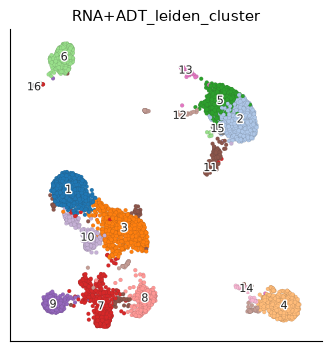

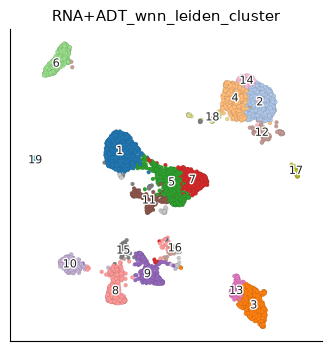

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [29]:
ds.plots.embedding(
    layout_key='RNA+ADT_UMAP',
    color_by='RNA+ADT_leiden_cluster',
    legend_loc='on_data',
)
ds.plots.embedding(
    layout_key='RNA+ADT_wnn_UMAP',
    color_by='RNA+ADT_wnn_leiden_cluster',
    legend_loc='on_data',
)